In [69]:
import pickle
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import ttest_ind
from scipy.optimize import curve_fit

In [70]:
with open('../data/supp_1/width.pkl', 'rb') as f:
    width = pickle.load(f)


In [72]:
len_track = 300
steps = 150
center = (steps - 1) // 2
x_data = np.arange(0, steps, 1)


func = lambda x, mu, sigma, fac, offset: fac * np.exp( - (x - mu)**2 / 2 / sigma**2) + offset

In [74]:
width_list = []

for data in width:

    rate_data = data["rate_avg"]

    widths = []

    for y_data in rate_data.T:
        argmax = np.argmax(y_data)
        y_data_centered = np.roll(y_data, shift=center - argmax)
        params, _ = curve_fit(func, x_data, y_data_centered, p0=[center, 10, 0.5 * np.max(y_data), 0.5])
        widths.append(2*2 * params[1])

    width_list.append(widths)
        

In [75]:
velocities = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

width_mean = []
width_std = []

for widths in width_list:
    width_mean.append(np.mean(widths))
    width_std.append(np.std(widths))

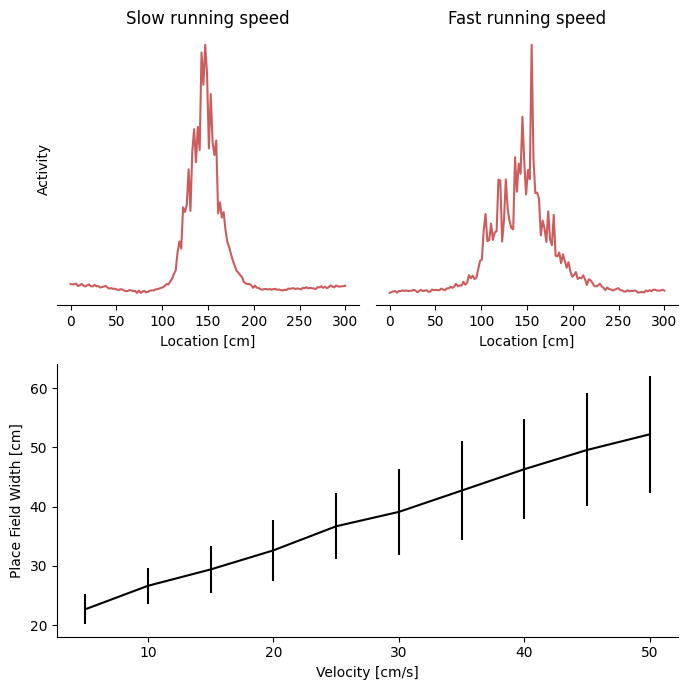

In [115]:
mosaic = """
    AB
    CC
    """
fig = plt.figure(figsize=(7,7))

ax_dict = fig.subplot_mosaic(mosaic)

spines = ['top', 'right', 'left']


for spine in spines:
    ax_dict['A'].spines[spine].set_visible(False)
    ax_dict['B'].spines[spine].set_visible(False)

ax_dict['A'].set_yticks([])
ax_dict['B'].set_yticks([])

ax_dict['A'].set_title('Slow running speed')
ax_dict['A'].set_xlabel('Location [cm]')
ax_dict['A'].set_ylabel('Activity')

ax_dict['A'].plot(np.linspace(0, len_track, steps), width[2]["rate_avg"][:, 1], c='indianred')

ax_dict['B'].set_title('Fast running speed')
ax_dict['B'].set_xlabel('Location [cm]')

ax_dict['B'].plot(np.linspace(0, len_track, steps), width[9]["rate_avg"][:, 6], c='indianred')


ax_dict['C'].spines['top'].set_visible(False)
ax_dict['C'].spines['right'].set_visible(False)
ax_dict['C'].set_xlabel('Velocity [cm/s]')
ax_dict['C'].set_xlabel('Velocity [cm/s]')
ax_dict['C'].set_ylabel('Place Field Width [cm]')

ax_dict['C'].errorbar(velocities, width_mean, width_std, c='k')
plt.tight_layout()

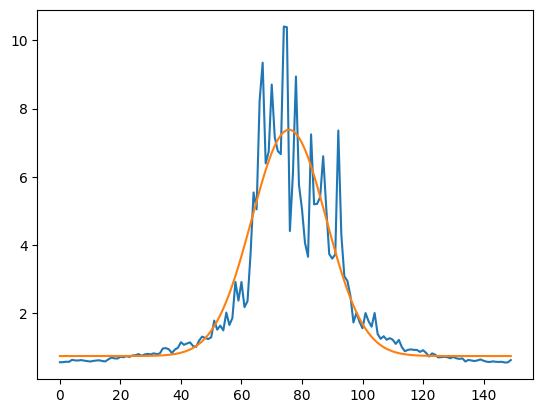

In [77]:
plt.plot(x_data, y_data_centered)
plt.plot(x_data, func(x_data, *params))

In [47]:
center

74

In [49]:
params, _ = curve_fit(func, x_data, y_data_centered, p0=[center, 20, 0.5 * np.max(y_data), 0.5])

In [50]:
params

array([71.14302186, 13.83142441,  4.1944706 ,  0.69691404])